In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/House_Rent_Dataset.csv")
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
df.shape

(4746, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 887.8 KB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Posted On,4746,81,2022-07-06,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BHK,4746.0,NaN,NaN,NaN,2.08386,0.832256,1.0,2.0,2.0,3.0,6.0
Rent,4746.0,NaN,NaN,NaN,34993.451327,78106.412937,1200.0,10000.0,16000.0,33000.0,3500000.0
Size,4746.0,NaN,NaN,NaN,967.490729,634.202328,10.0,550.0,850.0,1200.0,8000.0
Floor,4746,480,1 out of 2,379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Type,4746,3,Super Area,2446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Locality,4746,2235,Bandra West,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,4746,6,Mumbai,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Furnishing Status,4746,3,Semi-Furnished,2251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenant Preferred,4746,3,Bachelors/Family,3444,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.columns.tolist()

['Posted On',
 'BHK',
 'Rent',
 'Size',
 'Floor',
 'Area Type',
 'Area Locality',
 'City',
 'Furnishing Status',
 'Tenant Preferred',
 'Bathroom',
 'Point of Contact']

In [7]:
df.drop(columns=['Posted On', 'Floor', 'Area Locality', 'Tenant Preferred', 'Point of Contact'], inplace=True)

In [8]:
print(df.isnull().sum())

BHK                  0
Rent                 0
Size                 0
Area Type            0
City                 0
Furnishing Status    0
Bathroom             0
dtype: int64


In [9]:
# One hot encode categorical columns
df = pd.get_dummies(df, columns=['Area Type', 'City', 'Furnishing Status'], drop_first=True)

In [10]:
df = df.astype({col: int for col in df.select_dtypes(bool).columns})
print(df.shape)
print(df.columns.tolist())
print(df.head())

(4746, 13)
['BHK', 'Rent', 'Size', 'Bathroom', 'Area Type_Carpet Area', 'Area Type_Super Area', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai', 'Furnishing Status_Semi-Furnished', 'Furnishing Status_Unfurnished']
   BHK   Rent  Size  Bathroom  Area Type_Carpet Area  Area Type_Super Area  \
0    2  10000  1100         2                      0                     1   
1    2  20000   800         1                      0                     1   
2    2  17000  1000         1                      0                     1   
3    2  10000   800         1                      0                     1   
4    2   7500   850         1                      1                     0   

   City_Chennai  City_Delhi  City_Hyderabad  City_Kolkata  City_Mumbai  \
0             0           0               0             1            0   
1             0           0               0             1            0   
2             0           0               0             1        

In [11]:
X = df.drop(columns=['Rent'])
y = df['Rent']

print(X.shape)
print(y.shape)

(4746, 12)
(4746,)


In [12]:
print(f"Min rent: {y.min()}")
print(f"Max rent: {y.max()}")
print(f"Mean rent: {y.mean():.0f}")

Min rent: 1200
Max rent: 3500000
Mean rent: 34993


In [13]:
y.describe()

count    4.746000e+03
mean     3.499345e+04
std      7.810641e+04
min      1.200000e+03
25%      1.000000e+04
50%      1.600000e+04
75%      3.300000e+04
max      3.500000e+06
Name: Rent, dtype: float64

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
print(f"Training size: {X_train.shape}")
print(f"Testing size: {X_test.shape}")

Training size: (3796, 12)
Testing size: (950, 12)


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
print("Model trained successfully")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Model trained successfully
Coefficients: [ 3.28844874e+03  3.78905431e+01  1.17234932e+04 -4.95373945e+03
 -1.08235835e+04 -8.81475472e+03  9.41751064e+03 -1.78207789e+04
 -3.00268945e+03  5.27873547e+04 -8.51426339e+03 -7.95153529e+03]
Intercept: -23142.285847349303


In [18]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)

In [19]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 43654.73
R² Score: 0.52


In [20]:
comparison = pd.DataFrame({
    "Actual Rent": y_test,
    "Predicted Rent": y_pred
})

comparison.head(10)

,Actual Rent,Predicted Rent
1566,16000,29786.076764
3159,12000,17555.694407
538,28000,65828.251291
2630,8000,75241.590632
4418,46000,99299.836774
4679,17000,15377.886654
1181,57000,78396.802788
1957,9500,14067.131432
1344,400000,179465.455051
3410,15000,3357.849557


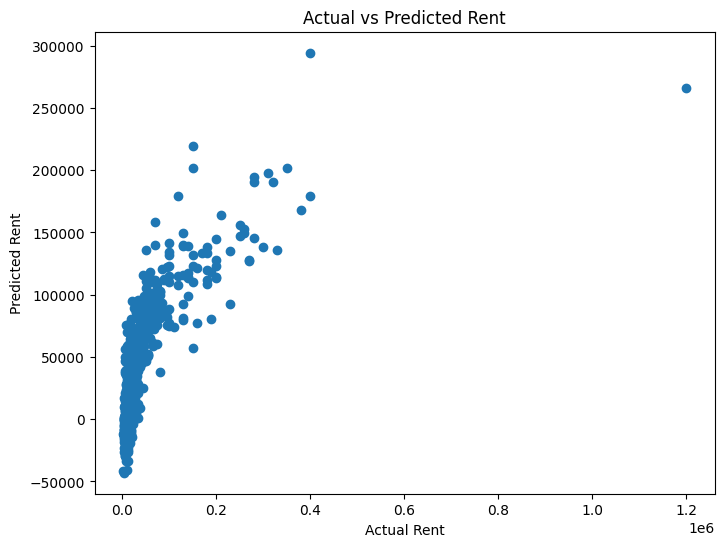

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")

plt.show()

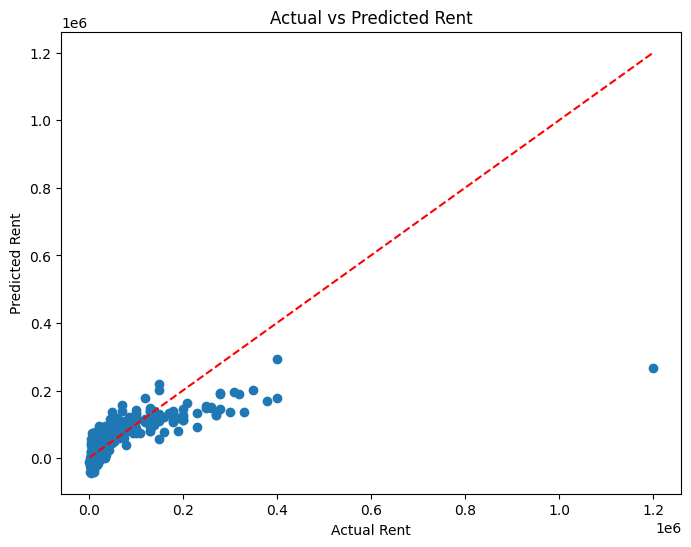

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")

plt.show()

In [23]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
9,City_Mumbai,52787.354689
2,Bathroom,11723.493239
6,City_Delhi,9417.510636
0,BHK,3288.448741
1,Size,37.890543
8,City_Kolkata,-3002.689452
3,Area Type_Carpet Area,-4953.739447
11,Furnishing Status_Unfurnished,-7951.535291
10,Furnishing Status_Semi-Furnished,-8514.263385
5,City_Chennai,-8814.754720


In [24]:
coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
9,City_Mumbai,52787.354689
2,Bathroom,11723.493239
6,City_Delhi,9417.510636
0,BHK,3288.448741
1,Size,37.890543
8,City_Kolkata,-3002.689452
3,Area Type_Carpet Area,-4953.739447
11,Furnishing Status_Unfurnished,-7951.535291
10,Furnishing Status_Semi-Furnished,-8514.263385
5,City_Chennai,-8814.754720


In [25]:
coefficients.sort_values(
    by="Coefficient"
).head(10)

,Feature,Coefficient
7,City_Hyderabad,-17820.778875
4,Area Type_Super Area,-10823.583461
5,City_Chennai,-8814.754720
10,Furnishing Status_Semi-Furnished,-8514.263385
11,Furnishing Status_Unfurnished,-7951.535291
3,Area Type_Carpet Area,-4953.739447
8,City_Kolkata,-3002.689452
1,Size,37.890543
0,BHK,3288.448741
6,City_Delhi,9417.510636


In [26]:
y_log = np.log1p(y)
y_log

0        9.210440
1        9.903538
2        9.741027
3        9.210440
4        8.922792
          ...    
4741     9.615872
4742    10.275086
4743    10.463132
4744    10.714440
4745     9.615872
Name: Rent, Length: 4746, dtype: float64

In [27]:
y_log.describe()

count    4746.000000
mean        9.878213
std         0.936595
min         7.090910
25%         9.210440
50%         9.680406
75%        10.404293
max        15.068274
Name: Rent, dtype: float64

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [29]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

In [30]:
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"RMSE: ₹{rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: ₹30891.10
R² Score: 0.76


### Log Transform on Target (Rent)

**Problem:** The Rent column was heavily right-skewed - 75% of houses rented for ₹33,000 or less, but the maximum was ₹35,00,000. This extreme outlier distorted the model's training.

**Why it's a problem:** RMSE squares each error before averaging, so a few huge-rent properties produced enormous squared errors that dominated the loss function. The model spent most of its effort trying to fit these extreme luxury properties, at the cost of accuracy on typical houses.

**Fix:** Applied `np.log1p()` to the target variable. This shrinks large values much more than small ones compressing the scale (max rent went from 3,500,000 to 15.07 in log space) so no single value dominates.

**Result:**
| Metric | Before | After |
|---|---|---|
| RMSE | ₹43,654 | ₹30,891 |
| R² | 0.52 | 0.76 |

R² of 0.76 means the model now explains 76% of the variation in rent using the available features. The remaining 24% is unexplained — likely due to missing 
features (floor, exact locality, building age) and the fact that rent doesn't scale linearly with size forever.

In [31]:
print(model.coef_)

[ 2.22432843e-01  4.74627824e-04  1.69010566e-01  2.36272306e-01
  5.69536412e-02 -6.25502271e-02  2.42093139e-01 -1.87748600e-01
 -3.11072954e-01  1.13040252e+00 -1.59820909e-01 -2.79686574e-01]


In [32]:
coefficients = pd.Series(model.coef_, index=X.columns)
coefficients_sorted = coefficients.sort_values(ascending=False)
print(coefficients_sorted)

City_Mumbai                         1.130403
City_Delhi                          0.242093
Area Type_Carpet Area               0.236272
BHK                                 0.222433
Bathroom                            0.169011
Area Type_Super Area                0.056954
Size                                0.000475
City_Chennai                       -0.062550
Furnishing Status_Semi-Furnished   -0.159821
City_Hyderabad                     -0.187749
Furnishing Status_Unfurnished      -0.279687
City_Kolkata                       -0.311073
dtype: float64


### Interpreting Model Coefficients

Since the categorical features were one-hot encoded with `drop_first=True`, one 
category from each group was dropped and became the "baseline" — every other 
category's coefficient is measured *relative to that baseline*, not as a 
standalone value.

**Baselines (dropped categories):**
- **City:** Bangalore
- **Furnishing Status:** Furnished
- **Area Type:** Built-up Area

**Key findings:**

- **City_Mumbai (+1.13)** is by far the strongest coefficient in the model. 
  Compared to Bangalore, being in Mumbai increases log(rent) substantially — 
  consistent with Mumbai being India's most expensive rental market.
- **City_Kolkata (-0.31)** has the strongest negative effect — rent in Kolkata 
  is notably lower than Bangalore, matching its reputation as a cheaper city.
- **Furnishing Status_Unfurnished (-0.28)** confirms the obvious: unfurnished 
  homes rent for less than furnished ones, more so than semi-furnished homes.
- **BHK (+0.22)** and **Bathroom (+0.17)** both push rent up, as expected — 
  more rooms and bathrooms generally mean a bigger, pricier property.
- **Size (+0.0005)** has a surprisingly tiny coefficient despite being an 
  intuitive driver of rent. This is likely because size is measured in raw 
  sq ft (a large-range number), so its effect per unit is naturally small — 
  and because City already captures a lot of the price variation that 
  correlates with typical property sizes in that city.

**Takeaway:** location (City) dominates rent prediction far more than physical 
attributes like size or bathroom count — which matches real-world intuition 
about the Indian rental market, where the same size flat can cost wildly 
different amounts depending on the city.

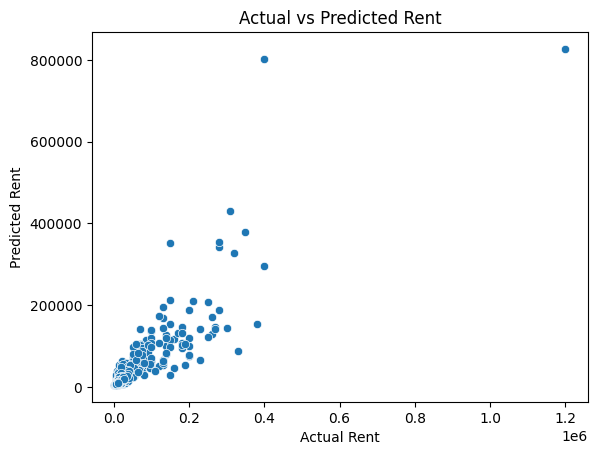

In [37]:
sns.scatterplot(x=y_test_actual, y=y_pred_actual)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")
plt.show()